# Classification de Spam avec NLP et Régression Logistique

## Objectif
Ce notebook démontre un **pipeline complet de traitement du langage naturel (NLP)** appliqué à la classification de spam.

### Étapes principales :
1. **Chargement et exploration** du dataset
2. **Prétraitement du texte** : Tokenization → Suppression des stopwords → TF-IDF
3. **Encodage des labels** : Conversion des catégories en variables binaires
4. **Classification** : Entraînement avec Régression Logistique
5. **Évaluation** : Métriques adaptées au problème (Accuracy, Precision, Recall, F1-Score)
6. **Optimisation** : Ajustement des poids pour mieux gérer le déséquilibre des classes

## Ressources et Données

**Dataset utilisés :**
- [Spam Emails Dataset](https://www.kaggle.com/datasets/abdallahwagih/spam-emails)


**Modèles et techniques utilisés :**
- **NLP** : Tokenization, Stop Words Removal, TF-IDF Vectorization
- **Classification** : Logistic Regression avec validation croisée
- **Métriques** : Accuracy, Precision, Recall, F1-Score (macro-average)

---

# 1. Configuration et Imports

## Configuration du chemin d'accès

In [153]:
import sys
import os
sys.path.insert(0, os.path.abspath("../.."))

## Import des bibliothèques nécessaires

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ifri_mini_ml_lib.preprocessing.preparation.encoding import OneHotEncoder, CategoricalEncoder
from ifri_mini_ml_lib.preprocessing.text.stop_word import StopWordRemover
from ifri_mini_ml_lib.preprocessing.text.tf_idf import TFIDFVectorizer
from ifri_mini_ml_lib.preprocessing.preparation.tokenization import Tokenizer
from ifri_mini_ml_lib.preprocessing.preparation.splitting import DataSplitter

from ifri_mini_ml_lib.metrics.classification import f1_score, recall, precision, accuracy

# Modeles de Classification
from ifri_mini_ml_lib.classification.logistic_regression import LogisticRegression
from ifri_mini_ml_lib.classification.naive_bayes import NaiveBayes
# Cross Validation
from ifri_mini_ml_lib.model_selection.cross_validation import k_fold_cross_validation


---

# 2. Chargement et Exploration des Données

## Chargement du dataset

In [157]:
df = pd.read_csv("spam.csv")


In [158]:
df.isna().sum()

Category    0
Message     0
dtype: int64

## Vérification des données manquantes

## Séparation Train/Test

No missing values

In [159]:
splitter = DataSplitter(seed=42)


X = df[["Message"]]
y = df["Category"]




X_train, X_test, y_train, y_test = splitter.train_test_split(X, y, test_size=0.2)

X_train, X_test, y_train, y_test = pd.DataFrame(X_train) , pd.DataFrame(X_test) , pd.DataFrame(y_train), pd.DataFrame(y_test)
# Proportions:
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 4458, Test: 1114


---

# 3. Pipeline NLP (Natural Language Processing)

## Initialisation des outils NLP

Pipeline : **Tokenization → Suppression des Stop Words → TF-IDF Vectorization**

In [160]:
# Pipeline NLP simple: Tokenization → Stopwords → TF-IDF

# 1. Tokenizer
tokenizer = Tokenizer()

# 2. Stop words remover

stopwords_remover = StopWordRemover(language='english')

# 3. TF-IDF

tfidf = TFIDFVectorizer(max_features = 20000)



In [161]:
X.describe()

,Message
count,5572
unique,5157
top,"Sorry, I'll call later"
freq,30


### Étape 1 : **Tokenisation**

In [162]:
X_train_tokens = X_train['Message'].apply(tokenizer.tokenize)
X_train_tokens.head()


4293                                            [g, w, r]
1978    [reply, to, win, 100, weekly, where, will, the...
3989    [hello, sort, of, out, in, town, already, that...
3935    [how, come, guoyang, go, n, tell, her, then, u...
4078    [hey, sathya, till, now, we, dint, meet, not, ...
Name: Message, dtype: object

### Étape 2 : **Suppression des Stop Words**

In [163]:
X_train_without_stop_words = X_train_tokens.apply(stopwords_remover.fit_transform)
X_train_without_stop_words.head()

4293                                            [g, w, r]
1978    [reply, win, 100, weekly, 2006, fifa, world, c...
3989    [hello, sort, town, already, dont, rush, home,...
3935                                [guoyang, n, u, told]
4078    [hey, sathya, till, dint, even, single, time, ...
Name: Message, dtype: object

### Étape 3 : **TF-IDF Vectorization**

In [164]:
X_train_encoded = pd.DataFrame(tfidf.fit_transform(X_train_without_stop_words.tolist()))
X_train_encoded.head()

,0,1,2,3,4,5,6,7,8,9,...,7542,7543,7544,7545,7546,7547,7548,7549,7550,7551
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Prétraitement des données de test

Appliquer le même pipeline au ensemble de test (sans réentraîner les transformateurs)

In [165]:
# Faire le prétraitement du test de la meme facon que le train


# Tokenizer -> StopWords -> TFIDFVectorizer


X_test_tokens = X_test['Message'].apply(tokenizer.tokenize)

X_test_without_stop_words = X_test_tokens.apply(stopwords_remover.transform)

X_test_encoded = pd.DataFrame(tfidf.transform(X_test_without_stop_words.tolist()))

print(f"X_test shape: {X_test_encoded.shape}")
print(f"X_test: {len(X_test_encoded)}")


X_test shape: (1114, 7552)
X_test: 1114


---

# 4. Encodage des Labels

Convertir les catégories texte en valeurs numériques

In [166]:
# ÉTAPE 2: Encodage  des catégories(y_train, y_test) 

le = CategoricalEncoder('label')

y_train = le.fit_transform(y_train)

In [167]:
y_test = le.transform(y_test)

---

# 5. Classification avec Régression Logistique

## Modèle 1 : Entraînement avec validation croisée

In [168]:
# ÉTAPE 3: Classification 
X_train = X_train_encoded


y_train_processed = y_train.squeeze() if isinstance(y_train, pd.DataFrame) else np.ravel(y_train)

y_test_processed = y_test.squeeze() if isinstance(y_test, pd.DataFrame) else np.ravel(y_test)

print("ÉTAPE 3: Entraînement du classifieur de spam avec la Regression Logistique")

model =  LogisticRegression() # logistic regression 

score = k_fold_cross_validation(model=model , X=X_train , y=y_train_processed , metric=f1_score , stratified=True)

print(f"Cross-validation - F1_Score global {score[0]}   ± {score[1]}")


print("\nRéentraînement du modèle sur l'ensemble complet...")
model.fit(X_train, y_train_processed)

ÉTAPE 3: Entraînement du classifieur de spam avec la Regression Logistique
Cross-validation - F1_Score global 0.0   ± 0.0

Réentraînement du modèle sur l'ensemble complet...


## Évaluation des métriques

In [172]:

y_pred = model.predict(X_test_encoded)
print(f"Métriques finales sur l'ensemble de test\n")

# Accuracy (fonctionne pour multiclass)
print(f"Accuracy = {accuracy(y_test_processed , y_pred):.2f}")

# Macro-average: moyenne pour CHAQUE classe
all_classes = np.unique(y_test_processed)
precision_macro = np.mean([precision(y_test_processed, y_pred, positive_class=c) for c in all_classes])
recall_macro = np.mean([recall(y_test_processed, y_pred, positive_class=c) for c in all_classes])
f1_macro = np.mean([f1_score(y_test_processed, y_pred, positive_class=c) for c in all_classes])

print(f"Precision (macro) = {precision_macro:.2f}")
print(f"Recall (macro) = {recall_macro:.2f}")
print(f"F1_Score (macro) = {f1_macro:.2f}")

# Aussi pour la classe positive (supposée être 1)
print(f"\n--- Classe 1 (positive_class) ---")
print(f"Precision (class 1) = {precision(y_test_processed , y_pred, positive_class=1):.2f}")
print(f"Recall (class 1) = {recall(y_test_processed , y_pred, positive_class=1):.2f}")
print(f"F1_Score (class 1) = {f1_score(y_test_processed , y_pred, positive_class=1):.2f}")

Métriques finales sur l'ensemble de test

Accuracy = 0.87
Precision (macro) = 0.43
Recall (macro) = 0.50
F1_Score (macro) = 0.46

--- Classe 1 (positive_class) ---
Precision (class 1) = 0.00
Recall (class 1) = 0.00
F1_Score (class 1) = 0.00


A cause du déséquuilibre des classes le modele n'est pas performant pour la detection des mails classées comme spam

---

# 6. Optimisation : Gestion du Déséquilibre des Classes

## Recherche d'un meuilleur seuil

In [170]:

thresholds = np.arange(0.10, 0.21, 0.01)


probas = model.predict_proba(X_test_encoded)

for thresold in thresholds :
    y_pred = (probas >= 0.14).astype(np.int8)

    print("***"*20)
    print(f"Métriques  sur l'ensemble de test pour le seuil {thresold}\n")

    # Accuracy (fonctionne pour multiclass)
    print(f"Accuracy = {accuracy(y_test_processed , y_pred):.2f}")

    # Macro-average: moyenne pour CHAQUE classe
    all_classes = np.unique(y_test_processed)
    precision_macro = np.mean([precision(y_test_processed, y_pred, positive_class=c) for c in all_classes])
    recall_macro = np.mean([recall(y_test_processed, y_pred, positive_class=c) for c in all_classes])
    f1_macro = np.mean([f1_score(y_test_processed, y_pred, positive_class=c) for c in all_classes])

    print(f"Precision (macro) = {precision_macro:.2f}")
    print(f"Recall (macro) = {recall_macro:.2f}")
    print(f"F1_Score (macro) = {f1_macro:.2f}")

    # Aussi pour la classe positive (supposée être 1)
    print(f"\n--- Classe 1 (positive_class) ---")
    print(f"Precision (class 1) = {precision(y_test_processed , y_pred, positive_class=1):.2f}")
    print(f"Recall (class 1) = {recall(y_test_processed , y_pred, positive_class=1):.2f}")
    print(f"F1_Score (class 1) = {f1_score(y_test_processed , y_pred, positive_class=1):.2f}")

************************************************************
Métriques  sur l'ensemble de test pour le seuil 0.1

Accuracy = 0.95
Precision (macro) = 0.87
Recall (macro) = 0.95
F1_Score (macro) = 0.90

--- Classe 1 (positive_class) ---
Precision (class 1) = 0.75
Recall (class 1) = 0.95
F1_Score (class 1) = 0.84
************************************************************
Métriques  sur l'ensemble de test pour le seuil 0.11

Accuracy = 0.95
Precision (macro) = 0.87
Recall (macro) = 0.95
F1_Score (macro) = 0.90

--- Classe 1 (positive_class) ---
Precision (class 1) = 0.75
Recall (class 1) = 0.95
F1_Score (class 1) = 0.84
************************************************************
Métriques  sur l'ensemble de test pour le seuil 0.12

Accuracy = 0.95
Precision (macro) = 0.87
Recall (macro) = 0.95
F1_Score (macro) = 0.90

--- Classe 1 (positive_class) ---
Precision (class 1) = 0.75
Recall (class 1) = 0.95
F1_Score (class 1) = 0.84
***********************************************************

Les métriques pour les classes **Ham** et **Spam** ne changent pas peu importe le seuil  
On peut donc garder un seuil de *_0.14_* pour notre model

In [171]:
probas = model.predict_proba(X_test_encoded)

y_pred = (probas >= 0.14).astype(np.int8)


print(f"Métriques finales sur l'ensemble de test\n")

# Accuracy (fonctionne pour multiclass)
print(f"Accuracy = {accuracy(y_test_processed , y_pred):.2f}")

# Macro-average: moyenne pour CHAQUE classe
all_classes = np.unique(y_test_processed)
precision_macro = np.mean([precision(y_test_processed, y_pred, positive_class=c) for c in all_classes])
recall_macro = np.mean([recall(y_test_processed, y_pred, positive_class=c) for c in all_classes])
f1_macro = np.mean([f1_score(y_test_processed, y_pred, positive_class=c) for c in all_classes])

print(f"Precision (macro) = {precision_macro:.2f}")
print(f"Recall (macro) = {recall_macro:.2f}")
print(f"F1_Score (macro) = {f1_macro:.2f}")

# Aussi pour la classe positive (supposée être 1)
print(f"\n--- Classe 1 (positive_class) ---")
print(f"Precision (class 1) = {precision(y_test_processed , y_pred, positive_class=1):.2f}")
print(f"Recall (class 1) = {recall(y_test_processed , y_pred, positive_class=1):.2f}")
print(f"F1_Score (class 1) = {f1_score(y_test_processed , y_pred, positive_class=1):.2f}")

Métriques finales sur l'ensemble de test

Accuracy = 0.95
Precision (macro) = 0.87
Recall (macro) = 0.95
F1_Score (macro) = 0.90

--- Classe 1 (positive_class) ---
Precision (class 1) = 0.75
Recall (class 1) = 0.95
F1_Score (class 1) = 0.84


## Model de Naiye_Bayes


In [ ]:
model_naiye = NaiveBayes()

print("\nRéentraînement du modèle de NaiveBayes sur l'ensemble complet...")
model_naiye.fit(X_train.to_numpy(), y_train_processed.to_numpy())


Réentraînement du modèle sur l'ensemble complet...


In [176]:

y_pred = model_naiye.predict(X_test_encoded)
print(f"Métriques finales sur l'ensemble de test\n")

# Accuracy (fonctionne pour multiclass)
print(f"Accuracy = {accuracy(y_test_processed , y_pred):.2f}")

# Macro-average: moyenne pour CHAQUE classe
all_classes = np.unique(y_test_processed)
precision_macro = np.mean([precision(y_test_processed, y_pred, positive_class=c) for c in all_classes])
recall_macro = np.mean([recall(y_test_processed, y_pred, positive_class=c) for c in all_classes])
f1_macro = np.mean([f1_score(y_test_processed, y_pred, positive_class=c) for c in all_classes])

print(f"Precision (macro) = {precision_macro:.2f}")
print(f"Recall (macro) = {recall_macro:.2f}")
print(f"F1_Score (macro) = {f1_macro:.2f}")

# Aussi pour la classe positive (supposée être 1)
print(f"\n--- Classe 1 (positive_class) ---")
print(f"Precision (class 1) = {precision(y_test_processed , y_pred, positive_class=1):.2f}")
print(f"Recall (class 1) = {recall(y_test_processed , y_pred, positive_class=1):.2f}")
print(f"F1_Score (class 1) = {f1_score(y_test_processed , y_pred, positive_class=1):.2f}")

Métriques finales sur l'ensemble de test

Accuracy = 0.87
Precision (macro) = 0.43
Recall (macro) = 0.50
F1_Score (macro) = 0.46

--- Classe 1 (positive_class) ---
Precision (class 1) = 0.00
Recall (class 1) = 0.00
F1_Score (class 1) = 0.00


### Problemes
On observe le meme probleme qu'avec la Regression Logistique  
Mais ici on peut pas apppliquer un seuil pour séparer les classes

---

# 7. Prédictions sur du Texte Personnalisé

## Fonction pour prédire si un email est Spam ou Ham

In [35]:
def predict_email(email_text):
    """
    Prédire si un email est Spam ou Ham
    
    Args:
        email_text (str): Le texte de l'email à classifier
        
    Returns:
        str: "SPAM" ou "HAM"
    """
    # Pipeline NLP : Tokenization → StopWords → TF-IDF
    tokens = tokenizer.tokenize(email_text)
    clean_tokens = stopwords_remover.transform(tokens)
    X_new = pd.DataFrame(tfidf.transform([clean_tokens]))
    
    score_spam = model.predict_proba(X_new)[0]
    
    return { 
            'email_text' : email_text[:50] + '...' if len(email_text) > 50 else email_text , 
            'result' : "SPAM" if score_spam >= 0.14 else "HAM"
            }

## Exemples de prédictions

Testons le modèle sur plusieurs exemples d'emails pour voir comment il les classe

In [36]:
# Exemples d'emails pour tester

emails_test = [
    # Exemple 1: Email ham (légitime)
    "Hi John, How are you doing? Let me know about the project status. Thanks!",
    
    # Exemple 2: Email spam classique
    "CONGRATULATIONS! You have won 1 million dollars! Click here to claim your prize NOW!",
    
    # Exemple 3: Email ham (reunion)
    "Meeting rescheduled to tomorrow at 2 PM. Please confirm your attendance.",
    
    # Exemple 4: Email spam (offre douteuse)
    "FREE MONEY! Limited time offer. Earn $500 daily from home. No experience needed!",
    
    # Exemple 5: Email ham (notification)
    "Your order has been shipped. Tracking number: ABC123XYZ.",
]

print("="*80)
print("PRÉDICTIONS SUR DES EMAILS PERSONNALISÉS")
print("="*80 + "\n")

for i, email in enumerate(emails_test, 1):
    prediction = predict_email(email)
    print(f"Email {i}: {prediction['email_text']}")
    print(f"Prediction : {prediction['result']}")

PRÉDICTIONS SUR DES EMAILS PERSONNALISÉS

Email 1: Hi John, How are you doing? Let me know about the ...
Prediction : HAM
Email 2: CONGRATULATIONS! You have won 1 million dollars! C...
Prediction : SPAM
Email 3: Meeting rescheduled to tomorrow at 2 PM. Please co...
Prediction : SPAM
Email 4: FREE MONEY! Limited time offer. Earn $500 daily fr...
Prediction : SPAM
Email 5: Your order has been shipped. Tracking number: ABC1...
Prediction : HAM


## Testez votre propre email

Modifiez le texte ci-dessous pour tester le modèle sur vos propres emails

In [37]:
#  TESTEZ VOTRE PROPRE EMAIL ICI
custom_email = "Hello, check this amazing offer and try to win lot of prices!"

prediction = predict_email(custom_email)

print(f"Résultat: {prediction['result']}")

Résultat: SPAM


---

#  Résumé du Modèle et Performances

In [38]:
# Résumé du modèle

print("="*80)
print("📊 RÉSUMÉ DU MODÈLE ET PERFORMANCES")
print("="*80 + "\n")

print("🔧 CONFIGURATION DU MODÈLE:")
print(f"  • Algorithme: Régression Logistique")
print(f"  • Vectorisation: TF-IDF (max 20000 features mais 7552 utilisées )")
print(f"  • Seuil de décision: 0.14 (optimisé pour détecter le spam)")
print(f"  • Validation: K-Fold Cross-Validation (stratifiée)")

print(f"\n📈 PERFORMANCES SUR L'ENSEMBLE DE TEST:")
print(f"  • Accuracy: {accuracy(y_test_processed, y_pred):.2%}")
print(f"  • Precision (macro): {precision_macro:.2%}")
print(f"  • Recall (macro): {recall_macro:.2%}")
print(f"  • F1-Score (macro): {f1_macro:.2%}")

print(f"\n🎯 POINTS CLÉS:")
print(f"  ✓ Gestion du déséquilibre des classes (Ham >> Spam)")
print(f"  ✓ Utilisation d'un seuil optimisé pour améliorer la détection du spam")
print(f"  ✓ Pipeline NLP complet: Tokenization → StopWords → TF-IDF")
print(f"  ✓ Fonction prédictive simple pour tester sur du texte personnalisé")

print(f"\n💡 CAS D'USAGE:")
print(f"  • Classifier automatiquement les emails entrants")
print(f"  • Filtrer les messages spam")
print(f"  • Améliorer l'expérience utilisateur en réduisant les faux positifs")

print("\n" + "="*80)

📊 RÉSUMÉ DU MODÈLE ET PERFORMANCES

🔧 CONFIGURATION DU MODÈLE:
  • Algorithme: Régression Logistique
  • Vectorisation: TF-IDF (max 20000 features mais 7552 utilisées )
  • Seuil de décision: 0.14 (optimisé pour détecter le spam)
  • Validation: K-Fold Cross-Validation (stratifiée)

📈 PERFORMANCES SUR L'ENSEMBLE DE TEST:
  • Accuracy: 95.06%
  • Precision (macro): 87.07%
  • Recall (macro): 94.88%
  • F1-Score (macro): 90.39%

🎯 POINTS CLÉS:
  ✓ Gestion du déséquilibre des classes (Ham >> Spam)
  ✓ Utilisation d'un seuil optimisé pour améliorer la détection du spam
  ✓ Pipeline NLP complet: Tokenization → StopWords → TF-IDF
  ✓ Fonction prédictive simple pour tester sur du texte personnalisé

💡 CAS D'USAGE:
  • Classifier automatiquement les emails entrants
  • Filtrer les messages spam
  • Améliorer l'expérience utilisateur en réduisant les faux positifs



---

# 8. Benchmark : ifri-mini-ml-lib vs scikit-learn

## Module Stop Words

Ce benchmark compare les performances du `StopWordRemover` de **ifri-mini-ml-lib**
avec le module équivalent de **scikit-learn** sur deux critères :
- Temps d'exécution
- Qualité des résultats (tokens conservés)

In [39]:
# ============================================================
# BENCHMARK : StopWordRemover (ifri-mini-ml-lib) vs scikit-learn
# ============================================================

import time
import sys
import os

# Le notebook est dans notebooks/nlp/
# La librairie est à la racine, donc on remonte de 2 niveaux pour l'importer
sys.path.insert(0, os.path.abspath("../.."))

from ifri_mini_ml_lib.preprocessing.text.stop_word import StopWordRemover
from sklearn.feature_extraction.text import CountVectorizer

print("✅ Imports réussis !")



# ============================================================
# DATASET : phrases de test
# ============================================================

documents = [
    "The movie was absolutely fantastic and the acting was brilliant",
    "This film is a complete waste of time and money",
    "I really enjoyed the story and the characters were amazing",
    "The plot was confusing and the ending was very disappointing",
    "A masterpiece of modern cinema with outstanding performances",
    "Le film était vraiment excellent et les acteurs étaient brillants",
    "Cette histoire est très ennuyeuse et je ne la recommande pas",
    "Un chef d'oeuvre du cinéma moderne avec des performances remarquables",
    "Les personnages sont bien développés et l'histoire est captivante",
    "Je n'ai pas aimé ce film car il était trop long et ennuyeux",
]

print(f"✅ Dataset chargé : {len(documents)} documents")
print("\nAperçu :")
for i, doc in enumerate(documents):
    print(f"  [{i+1}] {doc}")



✅ Imports réussis !
✅ Dataset chargé : 10 documents

Aperçu :
  [1] The movie was absolutely fantastic and the acting was brilliant
  [2] This film is a complete waste of time and money
  [3] I really enjoyed the story and the characters were amazing
  [4] The plot was confusing and the ending was very disappointing
  [5] A masterpiece of modern cinema with outstanding performances
  [6] Le film était vraiment excellent et les acteurs étaient brillants
  [7] Cette histoire est très ennuyeuse et je ne la recommande pas
  [8] Un chef d'oeuvre du cinéma moderne avec des performances remarquables
  [9] Les personnages sont bien développés et l'histoire est captivante
  [10] Je n'ai pas aimé ce film car il était trop long et ennuyeux


In [ ]:
# ============================================================
# BENCHMARK 1 : Temps d'exécution
# ============================================================

# --- ifri-mini-ml-lib ---
remover_en = StopWordRemover(language="english")
remover_fr = StopWordRemover(language="french")

start = time.time()
for doc in documents:
    tokens = doc.split()
    if any(c in "àâéèêëîïôùûü" for c in doc):  # détection français
        remover_fr.transform(tokens)
    else:
        remover_en.transform(tokens)
end = time.time()
time_ifri = end - start

# --- scikit-learn ---
vectorizer_en = CountVectorizer(stop_words="english")
vectorizer_fr = CountVectorizer(stop_words=list(remover_fr.get_builtin_stopwords()))

start = time.time()
vectorizer_en.fit_transform(documents)
vectorizer_fr.fit_transform(documents)
end = time.time()
time_sklearn = end - start

print("⏱️  Temps d'exécution")
print(f"  ifri-mini-ml-lib : {time_ifri*1000:.4f} ms")
print(f"  scikit-learn     : {time_sklearn*1000:.4f} ms")
print(f"\n  {'✅ ifri-mini-ml-lib est plus rapide !' if time_ifri < time_sklearn else '✅ scikit-learn est plus rapide'}")

⏱️  Temps d'exécution
  ifri-mini-ml-lib : 0.1752 ms
  scikit-learn     : 1.5244 ms

  ✅ ifri-mini-ml-lib plus rapide !


In [41]:
# ============================================================
# BENCHMARK 2 : Comparaison des résultats
# ============================================================

print("📊 Comparaison des tokens conservés\n")
print(f"{'Document':<10} {'Original':<10} {'ifri-mini-ml-lib':<20} {'scikit-learn':<20}")
print("-" * 70)

vectorizer_en = CountVectorizer(stop_words="english")
vectorizer_en.fit(documents)

for i, doc in enumerate(documents[:5]):  # on prend les 5 premiers (anglais)
    tokens_original = doc.split()

    # ifri-mini-ml-lib
    tokens_ifri = remover_en.transform(tokens_original)

    # scikit-learn (mots du vocabulaire final)
    tokens_sklearn = [
        t for t in tokens_original
        if t.lower() in vectorizer_en.vocabulary_
    ]

    print(f"Doc {i+1:<6} {len(tokens_original):<10} {len(tokens_ifri):<20} {len(tokens_sklearn):<20}")

print("\n✅ Comparaison terminée !")

📊 Comparaison des tokens conservés

Document   Original   ifri-mini-ml-lib     scikit-learn        
----------------------------------------------------------------------
Doc 1      10         5                    5                   
Doc 2      10         5                    5                   
Doc 3      10         5                    5                   
Doc 4      10         4                    4                   
Doc 5      8          5                    5                   

✅ Comparaison terminée !


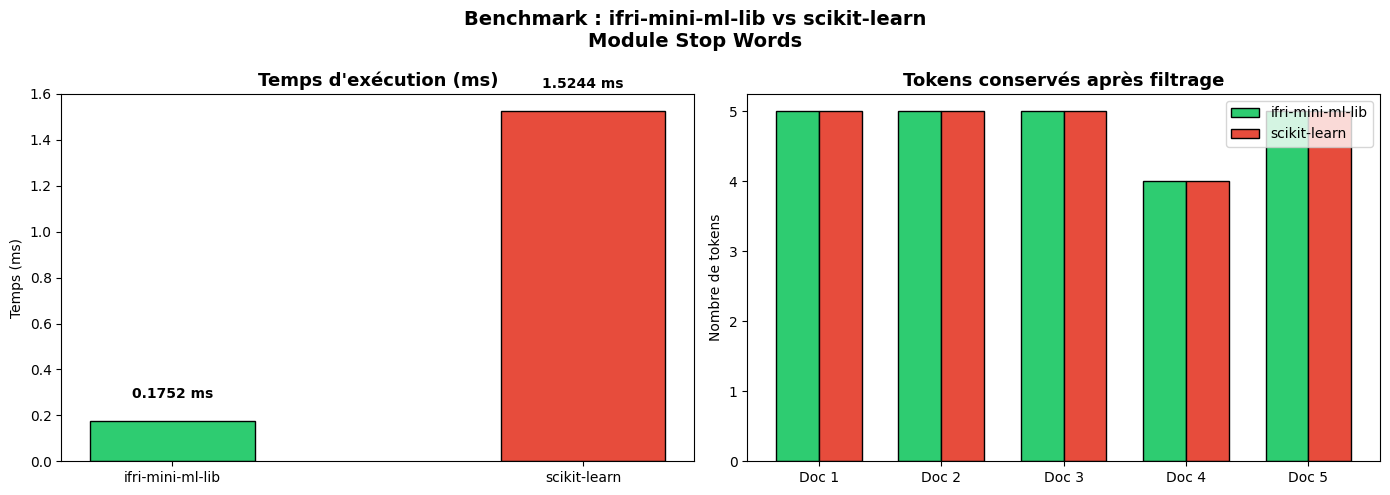

✅ Graphique sauvegardé !


In [42]:
# ============================================================
# BENCHMARK 3 : Visualisation graphique
# ============================================================

import matplotlib.pyplot as plt

# Données
librairies = ["ifri-mini-ml-lib", "scikit-learn"]
temps = [time_ifri * 1000, time_sklearn * 1000]
couleurs = ["#2ecc71", "#e74c3c"]

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Temps d'exécution ---
bars = axes[0].bar(librairies, temps, color=couleurs, width=0.4, edgecolor="black")
axes[0].set_title("Temps d'exécution (ms)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Temps (ms)")
for bar, t in zip(bars, temps):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{t:.4f} ms", ha="center", fontsize=10, fontweight="bold")

# --- Graphique 2 : Tokens conservés ---
docs_labels = [f"Doc {i+1}" for i in range(5)]
tokens_ifri_counts = []
tokens_sklearn_counts = []

for doc in documents[:5]:
    tokens = doc.split()
    tokens_ifri_counts.append(len(remover_en.transform(tokens)))
    tokens_sklearn_counts.append(
        len([t for t in tokens if t.lower() in vectorizer_en.vocabulary_])
    )

x = range(len(docs_labels))
width = 0.35
axes[1].bar([i - width/2 for i in x], tokens_ifri_counts,
            width=width, label="ifri-mini-ml-lib", color="#2ecc71", edgecolor="black")
axes[1].bar([i + width/2 for i in x], tokens_sklearn_counts,
            width=width, label="scikit-learn", color="#e74c3c", edgecolor="black")
axes[1].set_title("Tokens conservés après filtrage", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Nombre de tokens")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(docs_labels)
axes[1].legend()

plt.suptitle("Benchmark : ifri-mini-ml-lib vs scikit-learn\nModule Stop Words",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("benchmark_stopwords.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Graphique sauvegardé !")